# Convolutional Neural Network (Handwriting Recognition): To Be Improved
Convolutional neural networks imitate the structure of neurons that process images in the brain and use techniques to reduce neuron count while maintaining positional relationships in the data.

This is a convolutional network for the MNIST data set to recognize handwritten digits. In addition, you'll analyze how the convolutional neural network works differently than the densely connected network. You'll be able to feed images of handwritten digits to the model and it should recognize it. For example, you can draw down a digit on paper and then scan it, then upload as an image. If this seems too cumbersome, you're right. There's actually a quickdraw webcam model also in this repository that's much easier to use, based on the same model. (The folder name, is: "webcam_drawpad_model".)

Different handwritten digits dataset that can be used in combination with the MNIST set: https://www.kaggle.com/datasets/bistaumanga/usps-dataset 

Might also want to consider using the ARDIS DATASET IV if you want to train on more classic-looking digits: https://ardisdataset.github.io/ARDIS/ 

Using those two datasets in addition to the MNIST one would result in about 15,000 more images. Will go through the same process for preparing the data (converting to grayscale, etc.) and then combine all the datasets together.

# Data Preparation
To prepare your data, you'll import the libraries, load the MNIST dataset, format the data, and then perform one-hot encoding. For this network, you'll follow the process from the previous lessons.

## Importing TensorFlow and Keras
To get started, you'll import the TensorFlow and Keras libraries. In addition, you'll also import the NumPy and Matplotlib libraries, including the inline command.

In [1]:
# Import TensorFlow and Keras to create the neural network.
import tensorflow as tf
from tensorflow import keras
import h5py

# Import the MNIST dataset and Keras backend.
from tensorflow.keras.datasets import mnist
from tensorflow.keras import backend as K

# Import the NumPy and Matplotlib libraries and add the inline command.
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


## Load the Data
Now that you've set up the functions and the variables, you'll load the data to train the model and test its accuracy. In addition, you'll also print the shape of the training and test image datasets.

In [2]:
# Load the MNIST Data
def show_min_max(array, i):
    random_image = array[i]
    print("minimum and maximum pixel values in image: ", random_image.min(), random_image.max())

In [3]:
# Create a function which will plot a image from the dataset and display the image.
def plot_image(array, i, labels):
    plt.imshow(np.squeeze(array[i])) # show the image and convert shape
    plt.title(" Digit " + str(labels[i]))
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [4]:
# Create variables for the image row and column to keep track of your image size.
img_rows, img_cols = 28, 28

# Create a variable called num_classes and set the value to 10 output classes.
num_classes = 10

In [5]:
# MNIST train keys: ['image', 'label']
# USPS Feature Shape: (256,)
# MNIST Feature Shape: (28, 28)

import h5py
import cv2

train_file = 'mnist_train.hdf5'
test_file = 'mnist_test.hdf5'
output_file = 'mnist_combined.h5' # master dataset containing combined mnist sets

with h5py.File('usps.h5', 'r') as hf:
        X_train = hf['train/data'][:]
        y_train = hf['train/target'][:]
        X_test = hf['test/data'][:]
        y_test = hf['test/target'][:]

X_combined = np.concatenate([X_train, X_test], axis=0)
y_combined = np.concatenate([y_train, y_test], axis=0)

# combine the train and the test data of the USPS set into one large dataset for merging
with h5py.File('usps_combined.h5', 'w') as f:
         # Use the combined NumPy arrays for 'data'
         # Use 'maxshape' on the first dimension to allow for future appends
         f.create_dataset('data', data=X_combined, maxshape=(None, X_combined.shape[1]))
         f.create_dataset('target', data=y_combined, maxshape=(None,))

with h5py.File('mnist_train.hdf5', 'r') as f:
    print("MNIST Train Keys:", list(f.keys()))

# combine the train and the test data of the MNIST - will do a proper train-test split of the massive dataset later
with h5py.File(train_file, 'r') as f_train, h5py.File(test_file, 'r') as f_test:
    data_key = 'image'  
    label_key = 'label'

    train_shape = f_train[data_key].shape
    test_shape = f_test[data_key].shape
    
    total_rows = train_shape[0] + test_shape[0]
    feature_dims = train_shape[1:] 

    with h5py.File(output_file, 'w') as f_master:
        # We use maxshape=(None, *feature_dims) so this file can grow later
        master_data = f_master.create_dataset('all_data', shape=(total_rows, *feature_dims), 
                                              maxshape=(None, *feature_dims), dtype=f_train[data_key].dtype)
        master_labels = f_master.create_dataset('all_labels', shape=(total_rows,), 
                                                maxshape=(None,), dtype=f_train[label_key].dtype)
        
        # Copying chunks
        master_data[:train_shape[0]] = f_train[data_key][:]
        master_labels[:train_shape[0]] = f_train[label_key][:]
        
        master_data[train_shape[0]:] = f_test[data_key][:]
        master_labels[train_shape[0]:] = f_test[label_key][:]

print(f"MNIST combined into {output_file}. Shape: {total_rows} samples, Features: {feature_dims}")

with h5py.File('usps_combined.h5', 'r') as f1, h5py.File('mnist_combined.h5', 'r') as f2:
    print(f"USPS Feature Shape: {f1['data'].shape[1:]}")
    print(f"MNIST Feature Shape: {f2['all_data'].shape[1:]}")

with h5py.File("usps_combined.h5", 'r') as f_usps, h5py.File('mnist_combined.h5') as f_mnist:
       # 1. Prepare USPS (Resize 16x16 -> 28x28)
    print("Resizing USPS data...")
    usps_raw = f_usps['data'][:]
    # Reshape to 2D, resize, then flatten back to 784 to match MNIST if needed
    usps_resized = np.array([cv2.resize(img.reshape(16, 16), (28, 28)) for img in usps_raw])
    
    # 2. Prepare MNIST (Flatten 28x28 -> 784)
    # If your model expects flat vectors, flatten MNIST. 
    # If it's a CNN, keep both as (28, 28).
    mnist_data = f_mnist['all_data'][:]
    mnist_flat = mnist_data.reshape(-1, 784) 
    usps_flat = usps_resized.reshape(-1, 784)

    # 3. Combine
    final_data = np.concatenate([mnist_flat, usps_flat], axis=0)
    final_labels = np.concatenate([f_mnist['all_labels'][:], f_usps['target'][:]], axis=0)

    # 4. Save to the ultimate self-contained dataset
    with h5py.File('final_dataset.h5', 'w') as f_final:
        f_final.create_dataset('features', data=final_data, compression="gzip")
        f_final.create_dataset('targets', data=final_labels, compression="gzip")

print(f"Success! Final dataset shape: {final_data.shape}")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

MNIST Train Keys: ['image', 'label']
MNIST combined into mnist_combined.h5. Shape: 70000 samples, Features: (28, 28)
USPS Feature Shape: (256,)
MNIST Feature Shape: (28, 28)
Resizing USPS data...
Success! Final dataset shape: (79298, 784)
X_train: (7291, 256) | y_train: (7291,)
X_test:  (2007, 256)  | y_test:  (2007,)


## Performing the train-test-split with shuffling

In [6]:
from sklearn.model_selection import train_test_split
# PERFORM TRAIN-TEST SPLIT:
X_train_flat, X_test_flat, y_train, y_test = train_test_split(
    final_data,
    final_labels,
    test_size=0.2,
    shuffle=True,
    random_state=42,
    stratify=final_labels
)

X_train = X_train_flat.reshape(-1, 28, 28) # reshape the list of pixels into a 28x28 grid
X_test = X_test_flat.reshape(-1, 28, 28)

# add channel dimension
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis] # makes the shape (samples, 28, 28, 1)

print(f"Train Range: {X_train.min()} to {X_train.max()}")

Train Range: 0.0 to 255.0


## Data Formatting & One-Hot Encoding
For now, you'll reshape the data to be an appropriate size for your network. In addition, you'll employ one-hot encoding to replace the label on each image with a vectorized representation for the network to process. As a quick reference:

- X_train is train_images
- X_test is test_images
- y_train is train_labels
- y_test is test_labels

In [7]:
# Create an input_shape variable to keep track of the data's shape.
input_shape = (img_rows, img_cols, 1)

# Change the image values to between 0 and 1 by converting the training and test data into float32.
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Divide the images by 255 to make sure that each pixel is stored as a value between 0 and 1.
X_train /= 255
X_test /= 255

# Employ one-hot encoding on your training labels.
y_train = keras.utils.to_categorical(y_train, num_classes)

# Employ one-hot encoding on your test labels.
y_test = keras.utils.to_categorical(y_test, num_classes)

# Print the shape of the training data.
print(X_train[1232].shape)

(28, 28, 1)


# Building the Network
Like with the densely connected network, you're going to set up epochs. Remember, epochs are the rounds for training the network or how many times it should pass over the data.

You'll also define this network as **Sequential()**. Convolutional networks, like densely connected ones, take the output from one layer to feed in as input in the next layer. However, this network uses different types of layers.

## Import Model and Layers
To get started, you'll import the **Sequential** model and the **Dense**, **Flatten**, **Conv2D**, **MaxPooling2D**, and **Dropout** layers.

In the previous network that you created, you used the Dense, Flatten, and Dropout layers. In this network, you'll also use the **Conv2D**, **MaxPooling2D**, and **Dropout** layers.

Here is a breakdown of what each layer does:


*   The **Conv2D()** layer processes two-dimensional data, such as images, and creates a convolutional layer.
*   The **MaxPooling2D()** layer reduces the size of each data piece to keep the important information.
*   The **Dropout()** layer ensures the network isn't trained on a particular pattern. Therefore, the Dropout() layer ignores a certain amount of data at different iterations. For example, Dropout(0.3) randomly ignores 30% of neurons during an iteration.



In [8]:
# Import the Sequential model.
from tensorflow.keras.models import Sequential

# Import the Dense, Flatten, Conv2D, MaxPooling2D, and Dropout layers.
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras import layers

## Epochs and Model Type
Next, you'll set the epochs and model type. Every image in the dataset is passed through your model once. Generally, the more epochs you run, the better your results, but the longer it will take to train. Finding the balance between good results and reasonable runtime is a big challenge in training a model. To start, you'll run 10 epochs.

In [15]:
from tensorflow.keras import layers, models

# Create a variable called epochs
epochs = 10 # higher to reduce plateauing

# set up data augmentation to improve generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomInvert(factor=0.5)
])

# Create a new model object using the Keras Sequential command with data augmentation
model = models.Sequential([
    data_augmentation,
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(rate=0.5),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(units=32, activation='relu'),
    layers.Dropout(rate=0.5),
    layers.BatchNormalization(),
    layers.Dense(units=10, activation='softmax')
])

# Adding Layers
You added three fully connected (or dense) layers to your densely connected network. The layers in this network are convolutional and work differently.

Convolutional layers use small clusters of neurons called filters that are moved across the image and activated based on the pixels they see. These clusters learn to recognize features in the data.

You can adjust the number and size of filters in the layer — larger filters observe larger areas of the image at once, while smaller filters spot finer details. A higher filter count will allow a wider range of features to be recognized.

There are multiple advantages to having filters that work this way:


*   Small filters are more computationally efficient since they only examine a small portion of the image at once.
*   Just like in real life, the filter can do a better job by focusing on a small simple problem and ignoring the distraction of the rest of the image.
*   Because the filters are moved across the entire image, convolutional networks are good at identifying two images that have the same object but in different places in each image.





## Implementing Convolutional Layers
Keras provides functionality to easily create convolutional layers for your neural networks. You'll use the function Conv2D to create the first convolutional layer of your network.

In [ ]:
# This code and the following few cells are commented-out because the model is already compiled in the above cell.
# # Add a Conv2D layer to the network.
# model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=input_shape))

## Pooling Layers
Processing images with convolutional layers can get computationally complex. Successive layers of convolutions increase the number of neurons and computation time required.

**Pooling layers** are used by convolutional networks to manage the growth of complexity by simplifying and shrinking the dataset.

Pooling layers use a filter that moves across the data with a specified **stride**, simplifying the contents of each filter into a single value. This shrinks the size of the layer's output based on the filter's size.

This also helps reduce the network's **translation variance**, which is how sensitive the network is to an object's exact position in an image.

The most common pooling layer is a 2x2 filter with a stride of 2. This reduces the width and height of the input layer by half, simplifying the data without too much loss of specificity in the image.

## Adding a Pooling Layer
Keras uses the MaxPooling2D function to create 2D pooling layers.

In [12]:
# # Add a MaxPooling2D layer to the network.
# model.add(MaxPooling2D(pool_size=(2,2)))

## More Convolutional Layers
By design, convolutional layers can examine an image's low-level features. By adding more convolutional layers, the network can start to work with higher-level features.

This layer is defined the same way as the last one, except for more filters, 64, whereas the previous one had 32. Also, the input shape doesn't need to be defined since it's inferred from previous layer.

In [13]:
# # Add another Conv2D layer to the network.
# model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
# model.add(layers.BatchNormalization())

## Dropout Layers
A **dropout layer** takes a percentage of all the neurons in the input and deactivates them at random. This random dropout of neurons forces more of the network to adapt to the task.

Without a dropout layer, larger networks run the risk of growing overdependent on a small set of competent neurons rather than the whole network learning the task.

In [14]:
# # Add a Dropout layer to the network.
# model.add(Dropout(rate=0.5))

# # Add the final calculation layer, Conv2D layer to the network.
# model.add(Conv2D(32, (3,3), activation='relu'))

## Dense and Flatten Layers
At the end of the convolutional and pooling layers, you'll set up some neurons to help make your final classification decision. This will be a standard, fully connected layer of neurons. You'll first flatten the 2D image's filters to connect these layers.

Keras uses the **Flatten** function to create a flattening layer and the **Dense** function to create dense layers. In this case, the **Dense** layer will have an output size of 32 neurons.



In [15]:
# # Add a Flatten() layer to the network.
# model.add(Flatten())

# # Add a Dense layer to the network.
# model.add(Dense(units=32, activation='relu'))
# model.add(Dropout(rate=0.5))
# model.add(layers.BatchNormalization())

## Output Layers
Just like with your fully connected network, the final layer needs to shrink the previous layer down to just the number of possible classes. Like before, the decision is represented by the class with the highest weight.

In [10]:
# # Add another Dense layer to the network.
# model.add(Dense(units=10, activation='softmax'))

# Print a summary of your network.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Training the Network
Just like with your first network, you'll compile this network. The loss and metrics will be the same as your last network: categorical_crossentropy and accuracy. This time, however, you'll use a different training algorithm called **RMSProp**.

**RMSProp** is one of several different training algorithms Keras defines to do the computation that teaches the network how to improve.

The neural network aims to optimize the loss by making it as small as possible. RMSProp is one way the network can do this.

## Compile the Network
To compile the network, you'll set the optimizer as RMSProp. In addition, you'll use the categorical cross-entropy algorithm to calculate the loss and get the accuracy.



X_train raw shape: (63438, 28, 28, 1)  | total elements: 49735392
X_test  raw shape: (15860, 28, 28, 1)   | total elements: 12434240
y_train raw shape: (63438, 10)
y_test  raw shape: (15860, 10)

Elements per X_test sample:  784  (expect 784 = 28×28)
Elements per X_train sample: 784 (expect 784 = 28×28)
X_train channels before slice: 1
X_test  channels before slice: 1
New X_test shape: (15860, 28, 28, 1)
X_train: (63438, 28, 28, 1), y_train: (63438, 10, 10)
X_test: (15860, 28, 28, 1), y_test: (15860, 10, 10)


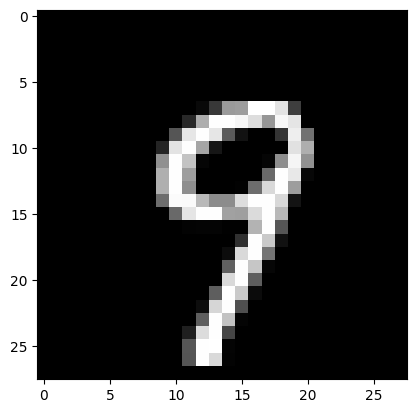

In [17]:
# inspect raw shapes in case of additional mismatches
print(f"X_train raw shape: {X_train.shape}  | total elements: {X_train.size}")
print(f"X_test  raw shape: {X_test.shape}   | total elements: {X_test.size}")
print(f"y_train raw shape: {y_train.shape}")
print(f"y_test  raw shape: {y_test.shape}")

n_train = y_train.shape[0]
n_test  = y_test.shape[0]

elements_per_test_sample  = X_test.size  // n_test
elements_per_train_sample = X_train.size // n_train

print(f"\nElements per X_test sample:  {elements_per_test_sample}  (expect 784 = 28×28)")
print(f"Elements per X_train sample: {elements_per_train_sample} (expect 784 = 28×28)")

# ── Step 1: Flatten to (N, 784) first, then rebuild to (N, 28, 28, 1) ─────
# This works regardless of how mangled the intermediate dimensions are
X_train = X_train.reshape(n_train, -1)   # → (n_train, 784)  confirms element count
X_test  = X_test.reshape(n_test,  -1)   # → (n_test,  784)  will CRASH here if
                                         #   n_test × 784 ≠ X_test.size (good!)

# ── Step 2: Slice to exactly 784 elements if extra channels are embedded ──
if X_train.shape[1] != 784:
    print(f"WARNING: X_train has {X_train.shape[1]} elements/sample, slicing to 784")
    X_train = X_train[:, :784]

if X_test.shape[1] != 784:
    print(f"WARNING: X_test has {X_test.shape[1]} elements/sample, slicing to 784")
    X_test = X_test[:, :784]

# Force X_test back to 1 channel
X_train = X_train.reshape(n_train, 28, 28, 1)
X_test = X_test.reshape(n_test, 28, 28, 1)

# verify channel count before slicing
print(f"X_train channels before slice: {X_train.shape[-1]}")  # expect 1 or 10
print(f"X_test  channels before slice: {X_test.shape[-1]}")

# slice and force to single channel
X_train = X_train[:, :, :, 0:1]
X_test  = X_test[:, :, :, 0:1]

# one-hot encode the labels, even though you don't knoww iitt...
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# Now verify the shape
print(f"New X_test shape: {X_test.shape}") # Should be (15860, 28, 28, 1)...except it wasn't. This is where it's going wrong.

# final verification
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

plt.imshow(X_train[5000].reshape(28, 28), cmap='gray')
plt.show()

# Add the compile function that calculates the loss and uses the optimizer parameter to set the optimization algorithm.
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=[
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')])


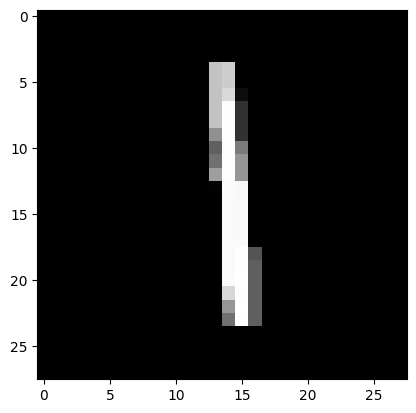

X_train: (63438, 28, 28, 1), y_train: (63438, 10, 10)
X_test: (15860, 28, 28, 1), y_test: (15860, 10, 10)


In [18]:
plt.imshow(X_train[3575].reshape(28, 28), cmap='gray')
plt.show()
# final Verification
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# Monitoring for Data Leakage
Why did you split into the train and test after merging the datasets?

In [19]:
# Flatten each image to a hashable row
train_hashes = set(map(tuple, X_train.reshape(len(X_train), -1).tolist()))
test_hashes  = set(map(tuple, X_test.reshape(len(X_test),  -1).tolist()))

overlap = train_hashes & test_hashes
print(f"Overlapping samples: {len(overlap)} / {len(X_test)} test samples")
print(f"Leak rate: {len(overlap)/len(X_test)*100:.1f}%")

class_counts = y_test.sum(axis=0)  # since y_test is one-hot
for i, count in enumerate(class_counts):
    print(f"Class {i}: {int(count)} samples ({count/len(y_test)*100:.1f}%)")

# There are no strongly dominant classes among the digits (0-9). Each one is 9-11% dominant.

Overlapping samples: 0 / 15860 test samples
Leak rate: 0.0%


TypeError: only length-1 arrays can be converted to Python scalars

## Training
The **fit()** function does the actual work of running the training. Now that the data has been processed and the model has been defined and compiled, it's time to train the model based on the data. In this network, you're going to use validation data to get an idea of how the network is performing with each epoch instead of just once at the end.

In [20]:
# This code segment forces labels back to 2D (samples, 10)
# We take the first vector from the extra dimensions created
if y_train.ndim > 2:
    y_train = y_train[:, 0, 0, :] if y_train.ndim == 4 else y_train[:, 0, :]
    
if y_test.ndim > 2:
    y_test = y_test[:, 0, 0, :] if y_test.ndim == 4 else y_test[:, 0, :]

# final shape check
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

# Add the fit function and set the input data for the model so the network doesn't rely on a pattern to learn.
model.fit(X_train, y_train, batch_size=32, epochs=epochs, validation_data=(X_test, y_test), shuffle=True)

# Shapes need to be this:
# X_train: (63438, 28, 28, 1) | y_train: (63438, 10)
# X_test:  (15860, 28, 28, 1)  | y_test:  (15860, 10)
# if you see anything else, you're absolutely fried!

X_train: (63438, 28, 28, 1) | y_train: (63438, 10)
X_test:  (15860, 28, 28, 1)  | y_test:  (15860, 10)
Epoch 1/10
1983/1983 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.9795 - loss: 0.3438 - precision: 0.9295 - recall: 0.8598 - val_accuracy: 0.9890 - val_loss: 0.1457 - val_precision: 0.9451 - val_recall: 0.9451
Epoch 2/10
1983/1983 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9879 - loss: 0.1855 - precision: 0.9397 - recall: 0.9396 - val_accuracy: 0.9945 - val_loss: 0.0755 - val_precision: 0.9724 - val_recall: 0.9724
Epoch 3/10
1983/1983 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9886 - loss: 0.1719 - precision: 0.9431 - recall: 0.9431 - val_accuracy: 0.9959 - val_loss: 0.0430 - val_precision: 0.9797 - val_recall: 0.9796
Epoch 4/10
1983/1983 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9900 - loss: 0.1556 - precision: 0.9502 - recall: 0.9502 - val_accuracy: 0.9956 - val_loss: 0.0589 - val_precision: 0.9779 - val_recall: 0.9779
Epoch 5/10
1983/1983 ━━━━━━━━━━━━━━━━━━━━

## Evaluation and Returning the Model
Now that you have created your model, compiled it, and trained it, you'll test it and see how accurate it is on data it has yet to see! Just like with your other network, you'll need to evaluate your network.

The **evaluate()** function returns an object that stores the evaluation results. You'll add a few arguments to this function so the network knows what data to test itself on.

Like the other stages, Tensorflow has some tools to help you out.

In [ ]:
# Update 5/4/2026: the validation accuracy significantly improved, and we now have an accuracy of 0.9988.
# This happened after decreasing the batch size from 48 to 32.

# Calculate the loss and accuracy of your model.
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
scores = model.evaluate(X_test, y_test, verbose=0)

# Print out the test accuracy.
print('Test accuracy:', scores[1])

496/496 - 2s - 4ms/step - accuracy: 0.9988 - loss: 0.0205 - precision: 0.9940 - recall: 0.9940


ValueError: too many values to unpack (expected 2)

## Exporting the Model
Like before, you'll save a copy of this trained model to use later.

In [22]:
# Export your model.
model.save('cnn_model_newdata_v3.h5')

## Test the model with generated images

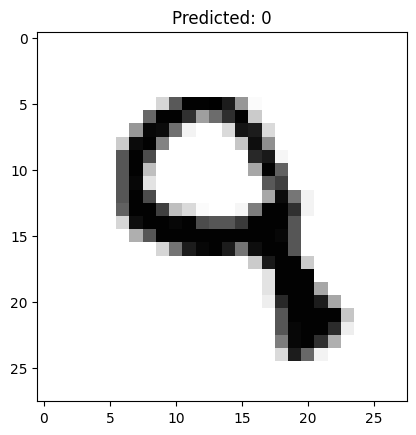

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def test_new_image(model_path, image_path, invert=False):
    # Load the trained model
    model = tf.keras.models.load_model(model_path)
    
    # Load and preprocess the image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(28, 28), color_mode="grayscale")
    x = tf.keras.preprocessing.image.img_to_array(img)
    x = x.astype('float32') / 255.0  # Normalize
    
    if invert:
        x = 1.0 - x  # Invert colors for white-on-black and additional generalization
    
    x = np.expand_dims(x, axis=[0, -1])  # Add batch and channel dims: (1, 28, 28, 1)
    
    # Predict
    prediction = model.predict(x, verbose=0)
    predicted_label = np.argmax(prediction)
    
    # Display
    plt.imshow(x[0, :, :, 0], cmap='gray')
    plt.title(f"Predicted: {predicted_label}")
    plt.show()
    
    return predicted_label, prediction

predicted, probs = test_new_image('cnn_model_newdata_v3.h5', 'test_images/9-test.png', invert=True)